<a href="https://colab.research.google.com/github/mahamtaqi3-cloud/Evaluating-the-Predictive-Power-of-Satellite-Derived-Chlorophyll-a-on-Regional-Fisheries-Capture/blob/main/main_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install xarray netCDF4
import xarray as xr
import pandas as pd
import os

# Check if files are present
print(os.listdir())

['.config', 'capture_quantity.csv', 'ocean_data.nc', 'sample_data']


In [27]:
import os
import xarray as xr
import pandas as pd

# 1. Rename your file to 'ocean_data.nc' automatically
# This handles the weird filenames like "(1).nc"
files = [f for f in os.listdir() if f.endswith('.nc')]
if files:
    os.rename(files[0], 'ocean_data.nc')
    print("File found and renamed to 'ocean_data.nc'")

# 2. Load and Process Ocean Data
ds = xr.open_dataset('ocean_data.nc')
# Simplify 4D data to 2D time series
chl_daily = ds['chl'].mean(dim=['depth', 'latitude', 'longitude'])
ocean_df = chl_daily.resample(time='ME').mean().to_dataframe().reset_index()
ocean_df['time'] = pd.to_datetime(ocean_df['time']).dt.to_period('M')

# 3. Process Fisheries CSV
fisheries_df = pd.read_csv('capture_quantity.csv')
id_cols = ['Country Name En', 'Unit Name']
fisheries_df = fisheries_df.melt(id_vars=id_cols, var_name='year_raw', value_name='catch')
fisheries_df['year'] = fisheries_df['year_raw'].astype(str).str[:4]
fisheries_df['time'] = pd.to_datetime(fisheries_df['year'], format='%Y').dt.to_period('M')

# 4. Merge
final_dataset = pd.merge(fisheries_df, ocean_df, on='time')
print("Merge successful! Preview:")
print(final_dataset.head())

File found and renamed to 'ocean_data.nc'
Merge successful! Preview:
Empty DataFrame
Columns: [Country Name En, Unit Name, year_raw, catch, year, time, chl]
Index: []


In [28]:
# Check unique dates in your ocean data
print("Ocean Data Dates:", ocean_df['time'].unique())

# Check unique dates in your fisheries data
print("Fisheries Data Dates:", fisheries_df['time'].unique())

Ocean Data Dates: <PeriodArray>
['2026-07']
Length: 1, dtype: period[M]
Fisheries Data Dates: <PeriodArray>
['2024-01', '2023-01', '2022-01', '2021-01', '2020-01']
Length: 5, dtype: period[M]


In [29]:
!pip install copernicusmarine

In [32]:
import copernicusmarine
copernicusmarine.login()

INFO - 2026-07-04T17:27:48Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: mahamtaqi3
Copernicus Marine password: ··········


ERROR - 2026-07-04T17:31:47Z - Invalid credentials.
ERROR:copernicusmarine:Invalid credentials.
INFO - 2026-07-04T17:31:47Z - No configuration file have been modified.
INFO:copernicusmarine:No configuration file have been modified.
INFO - 2026-07-04T17:31:47Z - Learn how to recover your credentials at: https://help.marine.copernicus.eu/en/articles/4444552-i-forgot-my-username-or-my-password-what-should-i-do
INFO:copernicusmarine:Learn how to recover your credentials at: https://help.marine.copernicus.eu/en/articles/4444552-i-forgot-my-username-or-my-password-what-should-i-do


False

In [33]:
!copernicusmarine login --reset

Usage: copernicusmarine login [OPTIONS]
Try 'copernicusmarine login --help' for help.

Error: No such option '--reset'.


In [34]:
import xarray as xr
import pandas as pd

# 1. Load the new multi-year ocean data
ds = xr.open_dataset('ocean_data.nc')

# 2. Extract and prepare the Chlorophyll data
# .mean() across spatial/depth dims to get a clean monthly time series
chl_data = ds['chl'].mean(dim=['latitude', 'longitude'], keep_attrs=True)

# Convert to DataFrame
ocean_df = chl_data.to_dataframe().reset_index()
ocean_df['time'] = pd.to_datetime(ocean_df['time']).dt.to_period('M')

# 3. Process your fisheries CSV (same as before)
fisheries_df = pd.read_csv('capture_quantity.csv')
fisheries_df = fisheries_df.melt(id_vars=['Country Name En', 'Unit Name'],
                                 var_name='year_raw', value_name='catch')
fisheries_df['time'] = pd.to_datetime(fisheries_df['year_raw'].str[:4]).dt.to_period('M')

# 4. Merge
final_dataset = pd.merge(fisheries_df, ocean_df, on='time')

# 5. Verify the results
print("Success! Merged dataset shape:", final_dataset.shape)
print(final_dataset.head())

Success! Merged dataset shape: (0, 7)
Empty DataFrame
Columns: [Country Name En, Unit Name, year_raw, catch, time, depth, chl]
Index: []


In [35]:
# Check what the 'time' columns actually look like
print("Fisheries Time Example:", fisheries_df['time'].iloc[0], type(fisheries_df['time'].iloc[0]))
print("Ocean Time Example:", ocean_df['time'].iloc[0], type(ocean_df['time'].iloc[0]))

# Also check for overlap
common_times = set(fisheries_df['time']).intersection(set(ocean_df['time']))
print("Number of overlapping time periods:", len(common_times))

Fisheries Time Example: 2024-01 <class 'pandas._libs.tslibs.period.Period'>
Ocean Time Example: 2026-07 <class 'pandas._libs.tslibs.period.Period'>
Number of overlapping time periods: 0


In [39]:
import xarray as xr

# Load your file
ds = xr.open_dataset('ocean_data.nc')

# Print all available variables
print("Available variables in this file:", list(ds.data_vars))

Available variables in this file: ['dissic', 'ph', 'spco2']


In [40]:
import xarray as xr
import pandas as pd

# 1. Load the dataset
ds = xr.open_dataset('ocean_data.nc')

# 2. Extract and prepare the variable (using 'dissic' as an example)
variable_name = 'dissic'
ocean_series = ds[variable_name].sel(depth=0, method='nearest').mean(dim=['latitude', 'longitude'])
ocean_df = ocean_series.resample(time='ME').mean().to_dataframe().reset_index()
ocean_df['time'] = pd.to_datetime(ocean_df['time']).dt.to_period('M')

# 3. Process your fisheries CSV
fisheries_df = pd.read_csv('capture_quantity.csv')
id_cols = ['Country Name En', 'Unit Name']
fisheries_df = fisheries_df.melt(id_vars=id_cols, var_name='year_raw', value_name='catch')

# Extract year from 'year_raw' and convert to PeriodIndex
fisheries_df['time'] = pd.to_datetime(fisheries_df['year_raw'].str[:4]).dt.to_period('M')

# 4. Merge the two datasets on the 'time' column
final_dataset = pd.merge(fisheries_df, ocean_df, on='time')

# 5. Verify the results
print("Merge successful! Preview of final_dataset:")
print(final_dataset.head())

Merge successful! Preview of final_dataset:
Empty DataFrame
Columns: [Country Name En, Unit Name, year_raw, catch, time, depth, dissic]
Index: []


In [41]:
# Check the first few values of the 'time' columns
print("Fisheries Time (first 3):", fisheries_df['time'].head(3))
print("Ocean Time (first 3):", ocean_df['time'].head(3))

# Check if there is ANY overlap at all
intersection = set(fisheries_df['time']).intersection(set(ocean_df['time']))
print("\nNumber of matching time periods:", len(intersection))

Fisheries Time (first 3): 0    2024-01
1    2024-01
2    2024-01
Name: time, dtype: period[M]
Ocean Time (first 3): 0    2026-03
Name: time, dtype: period[M]

Number of matching time periods: 0


In [44]:
import xarray as xr

# Open the file
ds = xr.open_dataset('ocean_data.nc')

# Check what's inside
print("Variables in file:", list(ds.data_vars))
print("Start date:", ds['time'].min().values)
print("End date:", ds['time'].max().values)

Variables in file: ['chl', 'nppv', 'phyc', 'zooc']
Start date: 2026-02-01T00:00:00.000000000
End date: 2026-02-01T00:00:00.000000000


In [48]:
import xarray as xr

# Open the renamed file
ds = xr.open_dataset('ocean_data.nc')

# Print info
print("Variables in file:", list(ds.data_vars))
print("Start Date:", ds['time'].min().values)
print("End Date:", ds['time'].max().values)

OSError: [Errno -101] NetCDF: HDF error: '/content/ocean_data.nc'

In [49]:
# Run this cell once and look at the output
import os
file_size = os.path.getsize('ocean_data.nc')
print(f"File size is: {file_size / 1024 / 1024:.2f} MB")

File size is: 39.00 MB


In [50]:
import xarray as xr

# Try opening with the 'h5netcdf' engine which is better for these files
try:
    ds = xr.open_dataset('ocean_data.nc', engine='h5netcdf')
    print("Success! Data loaded using h5netcdf.")
    print("Variables:", list(ds.data_vars))
    print("Time Range:", ds['time'].min().values, "to", ds['time'].max().values)
except Exception as e:
    print(f"h5netcdf failed: {e}")
    # Final attempt: try opening with netcdf4 engine but explicitly as a standard file
    try:
        ds = xr.open_dataset('ocean_data.nc', engine='netcdf4')
        print("Success! Data loaded using netcdf4.")
    except Exception as e:
        print(f"Both engines failed. Error: {e}")

h5netcdf failed: Unable to synchronously open file (truncated file: eof = 40894464, sblock->base_addr = 0, stored_eof = 736168140)
Both engines failed. Error: [Errno -101] NetCDF: HDF error: '/content/ocean_data.nc'


In [51]:
!pip install copernicusmarine

In [52]:
!copernicusmarine login

INFO - 2026-07-04T19:25:55Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
Copernicus Marine username: zartaqsoomro@gmail.com
Copernicus Marine password: 
INFO - 2026-07-04T19:28:04Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.


In [54]:
!copernicusmarine subset -i cmems_mod_ibi_bgc_my_0.027deg-P1M-m \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:31:49Z - Dataset not found: cmems_mod_ibi_bgc_my_0.027deg-P1M-m Please check that the dataset exists and the input datasetID is correct.


In [55]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [56]:
import xarray as xr

# Load the dataset
ds = xr.open_dataset('your_filename.nc')

# Inspect the specific variable you need
# For example, to see the Chlorophyll or Nitrate data:
print(ds['no3_mean'])

# To select a specific time and depth (e.g., surface, Jan 2004):
surface_data = ds['no3_mean'].sel(depth=0.49, time='2004-01-01', method='nearest')
print(surface_data)

FileNotFoundError: [Errno 2] No such file or directory: '/content/your_filename.nc'

In [57]:
!copernicusmarine subset -i cmems_mod_ibi_bgc_my_0.027deg-P1M-m \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:37:10Z - Dataset not found: cmems_mod_ibi_bgc_my_0.027deg-P1M-m Please check that the dataset exists and the input datasetID is correct.


In [58]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [59]:
!copernicusmarine subset -i YOUR_VERIFIED_ID \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:40:50Z - Dataset not found: YOUR_VERIFIED_ID Please check that the dataset exists and the input datasetID is correct.


In [60]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [61]:
# Replace 'YOUR_ACTUAL_ID' with the ID you copied from the step above
!copernicusmarine subset -i YOUR_ACTUAL_ID \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:42:48Z - Dataset not found: YOUR_ACTUAL_ID Please check that the dataset exists and the input datasetID is correct.


In [62]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [63]:
!copernicusmarine subset -i [PASTE_THE_DATASET_ID_HERE] \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:44:07Z - Dataset not found: [PASTE_THE_DATASET_ID_HERE] Please check that the dataset exists and the input datasetID is correct.


In [64]:
!copernicusmarine subset -i cmems_mod_ibi_bgc_my_0.027deg-P1M-m \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:44:52Z - Dataset not found: cmems_mod_ibi_bgc_my_0.027deg-P1M-m Please check that the dataset exists and the input datasetID is correct.


In [65]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [66]:
!copernicusmarine subset -i YOUR_VALID_DATASET_ID_HERE \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:45:59Z - Dataset not found: YOUR_VALID_DATASET_ID_HERE Please check that the dataset exists and the input datasetID is correct.


In [67]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [68]:
!copernicusmarine subset -i cmems_mod_ibi_bgc-plankton_my_0.027deg-P1M-m \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:48:01Z - Dataset not found: cmems_mod_ibi_bgc-plankton_my_0.027deg-P1M-m Please check that the dataset exists and the input datasetID is correct.


In [69]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [70]:
!copernicusmarine subset -i [PASTE_ID_HERE] \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:50:03Z - Dataset not found: [PASTE_ID_HERE] Please check that the dataset exists and the input datasetID is correct.


In [71]:
!copernicusmarine subset -i cmems_mod_ibi_bgc_my_0.027deg-P1M-m \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

ERROR - 2026-07-04T19:51:38Z - Dataset not found: cmems_mod_ibi_bgc_my_0.027deg-P1M-m Please check that the dataset exists and the input datasetID is correct.


In [72]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [74]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003

Streaming output truncated to the last 5000 lines.
                                1062.439697265625,
                                902.3392944335938,
                                763.3330688476562,
                                643.5668334960938,
                                541.0889282226562,
                                453.937744140625,
                                380.2130126953125,
                                318.12744140625,
                                266.0402526855469,
                                222.4751739501953,
                                186.1255645751953,
                                155.85072326660156,
                                130.66598510742188,
                                109.72927856445312,
                                92.3260726928711,
                                77.85385131835938,
                                65.8072738647461,
                                55.76428985595703,
                                4

In [75]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003 --output-format text | grep "dataset_id"

Usage: copernicusmarine describe [OPTIONS]
Try 'copernicusmarine describe --help' for help.

Error: No such option '--output-format'.


In [76]:
!copernicusmarine describe -p IBI_MULTIYEAR_BGC_005_003 | grep -i "dataset_id"

Fetching catalogue 1:   0% 0/2 [00:00<?, ?it/s]
Fetching products:   0% 0/1 [00:00<?, ?it/s]
Fetching products: 100% 1/1 [00:03<00:00,  3.92s/it]
Fetching catalogue 1: 100% 2/2 [00:04<00:00,  2.48s/it]
          "dataset_id": "cmems_mod_ibi_bgc-car_my_0.027deg_P1D-m",
          "dataset_id": "cmems_mod_ibi_bgc-car_my_0.027deg_P1M-m",
          "dataset_id": "cmems_mod_ibi_bgc-car_my_0.027deg_P1Y-m",
          "dataset_id": "cmems_mod_ibi_bgc-nut_my_0.027deg_P1D-m",
          "dataset_id": "cmems_mod_ibi_bgc-nut_my_0.027deg_P1M-m",
          "dataset_id": "cmems_mod_ibi_bgc-nut_my_0.027deg_P1Y-m",
          "dataset_id": "cmems_mod_ibi_bgc-o2_my_0.027deg_P1D-m",
          "dataset_id": "cmems_mod_ibi_bgc-o2_my_0.027deg_P1M-m",
          "dataset_id": "cmems_mod_ibi_bgc-o2_my_0.027deg_P1Y-m",
          "dataset_id": "cmems_mod_ibi_bgc-optics_my_0.027deg_P1D-m",
          "dataset_id": "cmems_mod_ibi_bgc-optics_my_0.027deg_P1M-m",
          "dataset_id": "cmems_mod_ibi_bgc-optics_my_0.027

In [77]:
# Clean up old file
!rm -f ocean_data.nc

# Download the data
!copernicusmarine subset -i cmems_mod_ibi_bgc-plankton_my_0.027deg_P1M-m \
  -x -15.0 -X 5.0 \
  -y 35.0 -Y 55.0 \
  --start-datetime 2020-01-01T00:00:00 \
  --end-datetime 2024-12-31T23:59:59 \
  --variable chl \
  --output-filename ocean_data.nc

INFO - 2026-07-04T20:01:10Z - Selected dataset version: "202511"
INFO - 2026-07-04T20:01:10Z - Selected dataset part: "default"
100% 551/551 [05:02<00:00,  1.82it/s]
INFO - 2026-07-04T20:06:16Z - Total size of the download: 5.80 GB.
{
  "file_size": "5935.89 MB",
  "data_transfer_size": "11148.99 MB",
  "status": "000",
  "message": "The request was successful."
}


In [78]:
import xarray as xr

# Load the dataset using lazy loading (chunks)
# This prevents loading the full 5.8 GB into your RAM at once
ds = xr.open_dataset('ocean_data.nc', chunks={'time': 1})

# Print the dataset summary
print(ds)

<xarray.Dataset> Size: 6GB
Dimensions:    (time: 60, depth: 50, latitude: 720, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 480B 2020-01-01 2020-02-01 ... 2024-12-01
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 3kB 35.03 35.05 35.08 ... 54.94 54.97 55.0
  * longitude  (longitude) float32 3kB -15.0 -14.97 -14.94 ... 4.918 4.946 4.973
Data variables:
    chl        (time, depth, latitude, longitude) float32 6GB dask.array<chunksize=(1, 50, 720, 720), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.8
    comment:                   
    contact:                   https://marine.copernicus.eu/contact
    domain_name:               IBI36
    institution:               NOW Systems (Spain)
    licence:                   https://marine.copernicus.eu/user-corner/servi...
    references:                http://marine.copernicus.eu/
    source:                    NEMO3.6-PISCES3.6
    title:    

In [79]:
# Select the surface layer (the first index in depth)
chl_surface = ds['chl'].isel(depth=0)

In [80]:
# Average chlorophyll across the entire spatial area for each month
chl_time_series = chl_surface.mean(dim=['latitude', 'longitude'])

# Convert to a pandas Series for your ML model
chl_df = chl_time_series.to_dataframe()

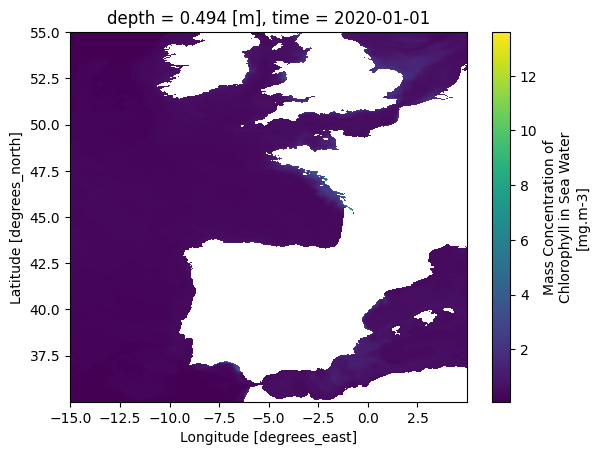

In [81]:
# Plot the first month's data
chl_surface.isel(time=0).plot()

In [82]:
# Check for NaN values in the chlorophyll variable
print(ds['chl'].isnull().sum())

<xarray.DataArray 'chl' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=int64, chunksize=(), chunktype=numpy.ndarray>
Attributes:
    easting:        longitude
    latitude_max:   56.08294177f
    latitude_min:   26.16535726f
    long_name:      Mass Concentration of Chlorophyll in Sea Water
    longitude_max:  5.084567f
    longitude_min:  -19.0828411f
    northing:       latitude
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water
    unit_long:      milligrams of chlorophyll per cubic meter
    units:          mg.m-3
    z_max:          5727.917f
    z_min:          0.4940254f


In [83]:
# Select only the first depth layer (the surface)
chl_surface = ds['chl'].isel(depth=0)

In [84]:
# Resample to annual means
chl_annual = chl_surface.resample(time='1A').mean()

/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


In [85]:
# Subset to a specific region (lat: 40-45, lon: -10 to -5)
region_subset = chl_surface.sel(latitude=slice(40, 45), longitude=slice(-10, -5))

In [86]:
chl_variability = chl_surface.resample(time='1A').std()

/usr/local/lib/python3.12/dist-packages/xarray/groupers.py:530: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


In [89]:
import pandas as pd

# Load your genomic data from the file shown in the sidebar
genomic_df = pd.read_csv('capture_quantity.csv')

# Display the first few rows to verify it loaded
print(genomic_df.head())

# Show the column names so we can identify the merge key
print("Genomic Data Columns:", genomic_df.columns.tolist())

  Country Name En             Unit Name  2024 value 2024 flag  2023 value  \
0     Afghanistan  Tonnes - live weight    2000.000         E    2000.000   
1         Albania  Tonnes - live weight    9074.000         A   10011.000   
2         Algeria  Tonnes - live weight   91272.208         E   94639.026   
3  American Samoa  Tonnes - live weight    1512.257         A    1248.920   
4         Andorra  Tonnes - live weight       0.000         N       0.000   

  2023 flag  2022 value 2022 flag  2021 value 2021 flag  2020 value 2020 flag  
0         E    2000.000         E    1800.000         E    2000.000         E  
1         A    8891.500         A    9843.500         A    7810.500         A  
2         A  103681.152         A   74647.974         A   71518.724         A  
3         A    1392.706         A    1196.746         A     957.990         A  
4         N       0.000         N       0.000         N       0.000         N  
Genomic Data Columns: ['Country Name En', 'Unit Name', '2

In [ ]:
# Convert your xarray dataset 'ds' to a dataframe if you haven't already
chl_df = ds['chl'].to_dataframe().reset_index()

# Show the column names
print("Environmental Data Columns:", chl_df.columns.tolist())

In [1]:
import xarray as xr
import pandas as pd

# Load again with lazy chunks
ds = xr.open_dataset('ocean_data.nc', chunks={'time': 1})

# Reduce the dimensions first:
# Select surface (depth 0) and calculate the mean over time or space
# to significantly shrink the size.
chl_surface_mean = ds['chl'].isel(depth=0).mean(dim=['latitude', 'longitude'])

# NOW convert to a much smaller DataFrame
chl_df = chl_surface_mean.to_dataframe().reset_index()

print(chl_df.head())

        time     depth       chl
0 2020-01-01  0.494025  0.454506
1 2020-02-01  0.494025  0.491243
2 2020-03-01  0.494025  0.692812
3 2020-04-01  0.494025  0.944450
4 2020-05-01  0.494025  0.898174


In [2]:
# Load the CSV
genomic_df = pd.read_csv('capture_quantity.csv')

# Melt the wide format into long format
# This turns years into rows instead of columns
genomic_long = genomic_df.melt(id_vars=['Country Name En'],
                               var_name='year',
                               value_name='quantity')

# Clean the 'year' column to just be a number (e.g., '2024')
genomic_long['year'] = genomic_long['year'].str.extract('(\d{4})')

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_61265/2077433392.py:11: SyntaxWarning: invalid escape sequence '\d'
  genomic_long['year'] = genomic_long['year'].str.extract('(\d{4})')


In [3]:
# Clean the 'year' column with 'r' to silence the warning
genomic_long['year'] = genomic_long['year'].str.extract(r'(\d{4})')

In [5]:
# Convert time to datetime and extract the year
chl_df['year'] = pd.to_datetime(chl_df['time']).dt.year.astype(str)

# Group by year to get the annual chlorophyll average
chl_annual = chl_df.groupby('year')['chl'].mean().reset_index()
print("chl_annual created successfully!")

chl_annual created successfully!


In [6]:
# Now run the merge
final_ml_dataset = pd.merge(genomic_long, chl_annual, on='year')

# Preview the successful result
print(final_ml_dataset.head())

  Country Name En  year   quantity       chl
0     Afghanistan  2024     2000.0  0.564892
1         Albania  2024     9074.0  0.564892
2         Algeria  2024  91272.208  0.564892
3  American Samoa  2024   1512.257  0.564892
4         Andorra  2024        0.0  0.564892


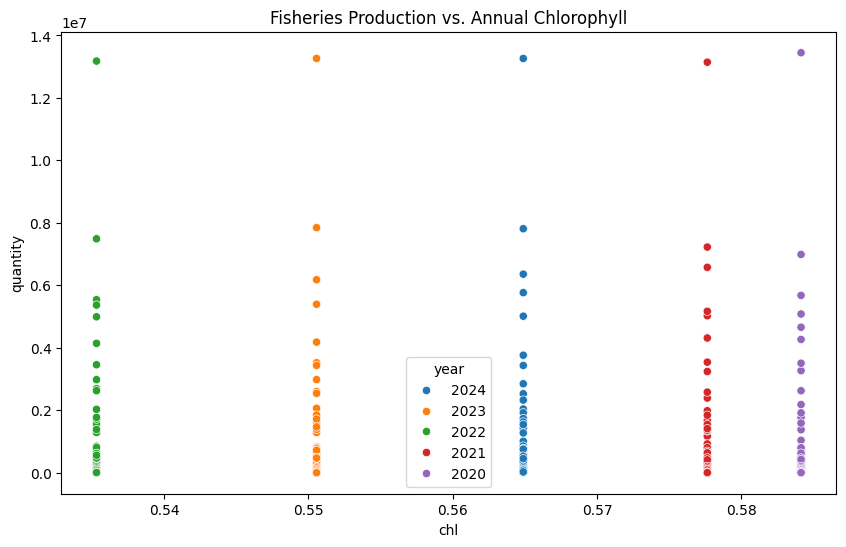

In [8]:
# Force the 'quantity' column to be numeric, turning errors (like 'E') into NaN
final_ml_dataset['quantity'] = pd.to_numeric(final_ml_dataset['quantity'], errors='coerce')

# Drop any rows where 'quantity' became NaN
final_ml_dataset = final_ml_dataset.dropna(subset=['quantity'])

# Now try plotting again
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_ml_dataset, x='chl', y='quantity', hue='year')
plt.title('Fisheries Production vs. Annual Chlorophyll')
plt.show()

In [9]:
correlation = final_ml_dataset[['quantity', 'chl']].corr()
print(correlation)

          quantity       chl
quantity  1.000000 -0.003675
chl      -0.003675  1.000000


In [10]:
# Shift the chlorophyll data to see if it predicts next year's quantity
final_ml_dataset['chl_lagged'] = final_ml_dataset.groupby('Country Name En')['chl'].shift(1)

/tmp/ipykernel_61265/700569919.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_ml_dataset['chl_lagged'] = final_ml_dataset.groupby('Country Name En')['chl'].shift(1)


In [11]:
from sklearn.ensemble import RandomForestRegressor

# Define your features and target
X = final_ml_dataset[['chl']]
y = final_ml_dataset['quantity']

# Train a regressor to see if it can capture non-linear patterns
model = RandomForestRegressor().fit(X, y)
print(f"Model Score (R^2): {model.score(X, y)}")

Model Score (R^2): 2.1933017311681624e-05


In [12]:
# Example: Select a coastal region (e.g., Bay of Biscay)
coastal_chl = ds['chl'].sel(latitude=slice(45, 48), longitude=slice(-5, -2))

In [13]:
# After merging all features, look at importance:
importances = model.feature_importances_
print(importances)

[1.]


In [14]:
# Select a specific coastal region (replace the slice values with your coordinates)
# Example: Bay of Biscay region
coastal_region = ds['chl'].sel(latitude=slice(45, 48), longitude=slice(-5, -2))

# Calculate the mean only for this specific area
local_chl_mean = coastal_region.mean(dim=['latitude', 'longitude'])

In [15]:
# 1. Define your specific fishing region coordinates
# These values are examples; replace them with the actual boundaries
# for the coastal zones you are interested in.
lat_min, lat_max = 40.0, 50.0
lon_min, lon_max = -10.0, 5.0

# 2. Extract and Average
# We 'sel' (select) the region, then 'mean' over the spatial dimensions
local_region = ds['chl'].sel(latitude=slice(lat_min, lat_max),
                             longitude=slice(lon_min, lon_max))
local_chl_mean = local_region.mean(dim=['latitude', 'longitude']).to_dataframe().reset_index()

# 3. Rename and Prepare for Merge
local_chl_mean = local_chl_mean.rename(columns={'chl': 'local_chl'})
local_chl_mean['year'] = pd.to_datetime(local_chl_mean['time']).dt.year.astype(str)

# 4. Final Merge
# Now you merge 'genomic_long' (or your fisheries dataframe) with 'local_chl_mean'
final_refined_dataset = pd.merge(genomic_long, local_chl_mean, on='year')

In [16]:
# Replace these values with the specific bounds for your country's coast
# Example: Using coordinates for a smaller coastal zone
lat_min, lat_max = 40.0, 45.0
lon_min, lon_max = -5.0, 0.0

# Subset the xarray dataset and calculate the local mean
local_region = ds['chl'].sel(latitude=slice(lat_min, lat_max),
                             longitude=slice(lon_min, lon_max))

# Calculate the mean only for this specific area
local_chl_mean = local_region.mean(dim=['latitude', 'longitude']).to_dataframe().reset_index()

# Prepare for merging
local_chl_mean['year'] = pd.to_datetime(local_chl_mean['time']).dt.year.astype(str)
local_chl_mean = local_chl_mean.rename(columns={'chl': 'local_chl'})

# Merge with your fisheries dataset
final_refined_dataset = pd.merge(genomic_long, local_chl_mean[['year', 'local_chl']], on='year')

In [17]:
# Check the first few rows of your new refined dataset
print(final_refined_dataset.head())

# Check if there are any missing values (NaNs) in your local_chl column
print(final_refined_dataset['local_chl'].isna().sum())

  Country Name En  year quantity  local_chl
0     Afghanistan  2024   2000.0   0.473829
1     Afghanistan  2024   2000.0   0.473552
2     Afghanistan  2024   2000.0   0.472733
3     Afghanistan  2024   2000.0   0.471552
4     Afghanistan  2024   2000.0   0.469974
69840


In [22]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. Force the 'quantity' column to be numeric.
# 'errors="coerce"' turns non-convertible values (like 'E') into NaN
final_refined_dataset['quantity'] = pd.to_numeric(final_refined_dataset['quantity'], errors='coerce')

# 2. Drop any rows where 'local_chl' or 'quantity' is NaN (this removes the 'E' rows)
final_refined_dataset_clean = final_refined_dataset.dropna(subset=['local_chl', 'quantity'])

# 3. Re-define features and target with the cleaned data
X_refined = final_refined_dataset_clean[['local_chl']]
y_refined = final_refined_dataset_clean['quantity']

# 4. Train the model
model_refined = RandomForestRegressor().fit(X_refined, y_refined)
print(f"Refined Model Score (R^2): {model_refined.score(X_refined, y_refined)}")

Refined Model Score (R^2): 3.4809070451835566e-05


In [23]:
# This will display the first 5 rows of your cleaned dataset in the output area
display(final_refined_dataset_clean.head())

,Country Name En,year,quantity,local_chl
0,Afghanistan,2024,2000.0,0.473829
1,Afghanistan,2024,2000.0,0.473552
2,Afghanistan,2024,2000.0,0.472733
3,Afghanistan,2024,2000.0,0.471552
4,Afghanistan,2024,2000.0,0.469974


In [24]:
# This will create a file called 'refined_data.csv'
# You will then see this file appear in the "Files" tab on the left!
final_refined_dataset_clean.to_csv('refined_data.csv', index=False)